<a href="https://colab.research.google.com/github/Gaganajain/java_project/blob/main/Stock_Market_Forecasting_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance

In [ ]:
import yfinance as yf

In [ ]:
def fetch_data(ticker="AAPL", start="2015-01-01", end="2023-12-31"):
    data = yf.download(ticker, start=start, end=end)
    data = data[["Close"]]
    data.dropna(inplace=True)
    data = data.asfreq('B')  # Business days
    data.fillna(method='ffill', inplace=True)
    return data

In [ ]:
df = fetch_data()
print(df.head())

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

Price           Close
Ticker           AAPL
Date                 
2015-01-02  24.288584
2015-01-05  23.604328
2015-01-06  23.606554
2015-01-07  23.937569
2015-01-08  24.857306



<ipython-input-3-f474cd073323>:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import matplotlib.pyplot as plt

def plot_data(data):
    plt.figure(figsize=(14, 5))
    plt.plot(data, label="Close Price")
    plt.title("Stock Closing Price")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.grid()
    plt.show()

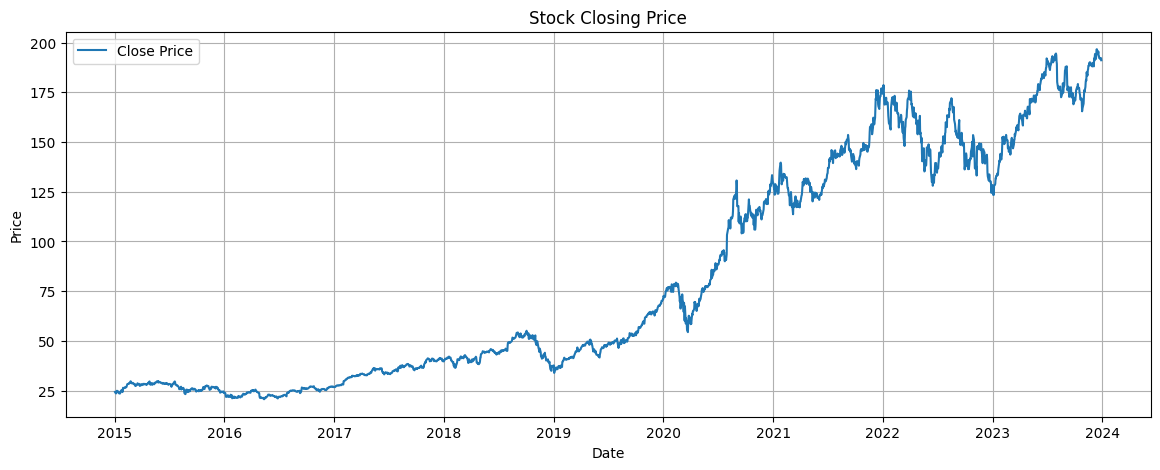

In [ ]:
plot_data(df)

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt
import matplotlib.pyplot as plt

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt
import matplotlib.pyplot as plt

def arima_model(data):
    train = data[:-100]
    test = data[-100:]

    model = ARIMA(train, order=(5, 1, 0))
    model_fit = model.fit()

    forecast = model_fit.forecast(steps=100)

    rmse = sqrt(mean_squared_error(test, forecast))
    print(f"ARIMA RMSE: {rmse:.2f}")

    plt.figure(figsize=(14, 5))
    plt.plot(test.index, test.values, label="Actual")
    plt.plot(test.index, forecast, label="Forecast", linestyle='--')
    plt.title("ARIMA Forecast")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.grid()
    plt.show()

[*********************100%***********************]  1 of 1 completed
<ipython-input-3-f474cd073323>:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)


ARIMA RMSE: 9.83


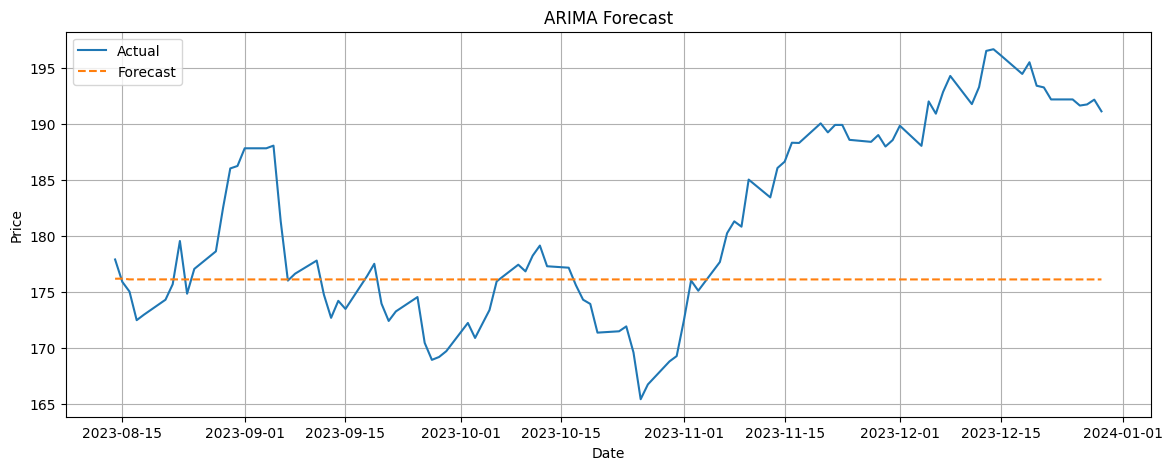

In [ ]:
df = fetch_data()
arima_model(df["Close"])

In [ ]:
!pip install prophet

In [ ]:
from prophet import Prophet

In [ ]:

from prophet import Prophet
from sklearn.metrics import mean_squared_error
from math import sqrt
import matplotlib.pyplot as plt

def prophet_model(data):
    df = data.reset_index()
    df.columns = ['ds', 'y']
    train = df[:-100]
    test = df[-100:]

    model = Prophet(daily_seasonality=True)
    model.fit(train)

    future = model.make_future_dataframe(periods=100)
    forecast = model.predict(future)

    pred = forecast[['ds', 'yhat']].iloc[-100:]
    rmse = sqrt(mean_squared_error(test['y'].values, pred['yhat'].values))
    print(f"Prophet RMSE: {rmse:.2f}")

    model.plot(forecast)
    plt.title("Prophet Forecast")
    plt.show()

[*********************100%***********************]  1 of 1 completed
<ipython-input-3-f474cd073323>:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)
DEBUG:cmdstanpy:input tempfile: /tmp/tmpngz5qm5a/xf3hpb9i.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpngz5qm5a/81_z5ayk.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=18332', 'data', 'file=/tmp/tmpngz5qm5a/xf3hpb9i.json', 'init=/tmp/tmpngz5qm5a/81_z5ayk.json', 'output', 'file=/tmp/tmpngz5qm5a/prophet_modelnyvzovf0/prophet_model-20250515164650.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
16:46:50 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
16:46:51 - cmdstanpy - INFO - Chain [1] done processing


Prophet RMSE: 18.04


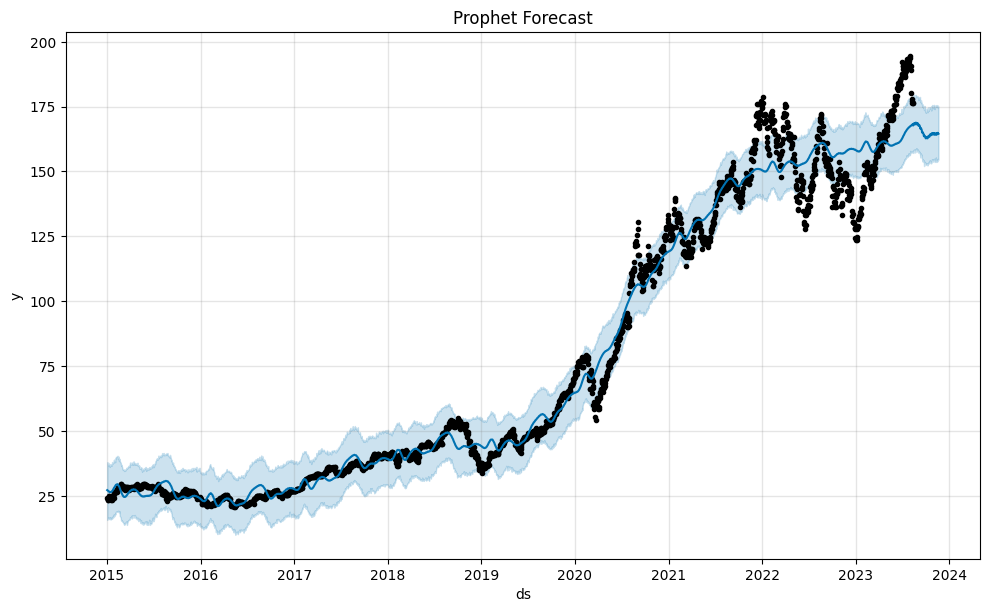

In [ ]:
df = fetch_data()
prophet_model(df["Close"])

In [ ]:
!pip install tensorflow

In [ ]:
!pip install --upgrade tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 75.3 MB/s eta 0:00:00
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.18.0
    Uninstalling tensorboard-2.18.0:
      Successfully uninstalled tensorboard-2.18.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.18.0
    Uninstalling tensorflow-2.18.0:
      Successfully uninstalled tensorflow-2.18.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.11.0 requires tensorflow==2.18.0, but you have tens

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error
from math import sqrt

def lstm_model(data):
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)

    X, y = [], []
    for i in range(60, len(scaled_data)):
        X.append(scaled_data[i - 60:i, 0])
        y.append(scaled_data[i, 0])
    X, y = np.array(X), np.array(y)

    X = X.reshape(X.shape[0], X.shape[1], 1)

    model = Sequential()
    model.add(LSTM(units=50, return_sequences=True, input_shape=(X.shape[1], 1)))
    model.add(LSTM(units=50))
    model.add(Dense(1))

    model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
    model.fit(X, y, epochs=5, batch_size=32, verbose=1)

    test_data = scaled_data[-160:]
    X_test = []
    for i in range(60, len(test_data)):
        X_test.append(test_data[i - 60:i, 0])
    X_test = np.array(X_test)
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

    predictions = model.predict(X_test)
    predictions = scaler.inverse_transform(predictions)
    actual = data[-100:].values

    rmse = sqrt(mean_squared_error(actual, predictions))
    print(f"LSTM RMSE: {rmse:.2f}")

    plt.figure(figsize=(14, 5))
    plt.plot(actual, label="Actual")
    plt.plot(predictions, label="LSTM Forecast")
    plt.legend()
    plt.title("LSTM Forecast")
    plt.show()

[*********************100%***********************]  1 of 1 completed
<ipython-input-3-f474cd073323>:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)


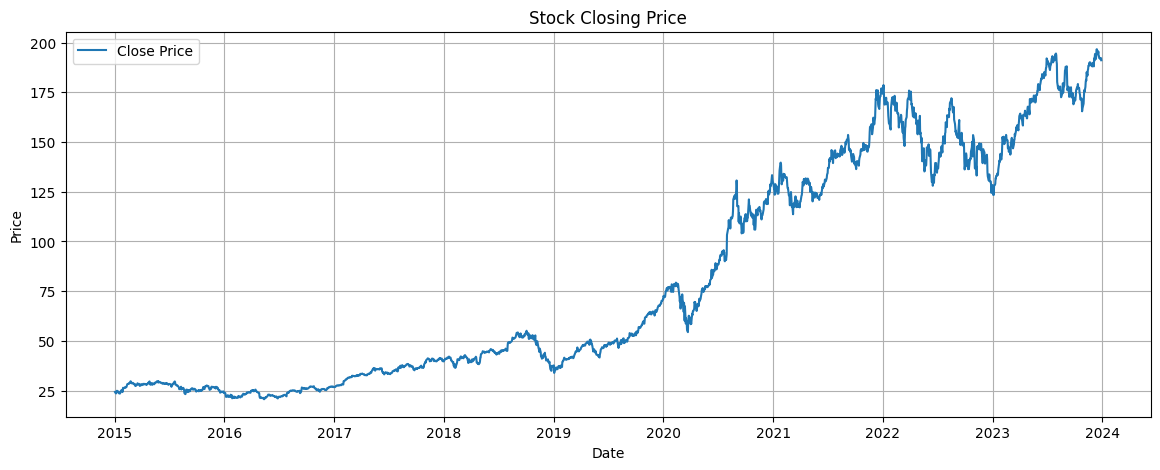


--- ARIMA ---
ARIMA RMSE: 9.83


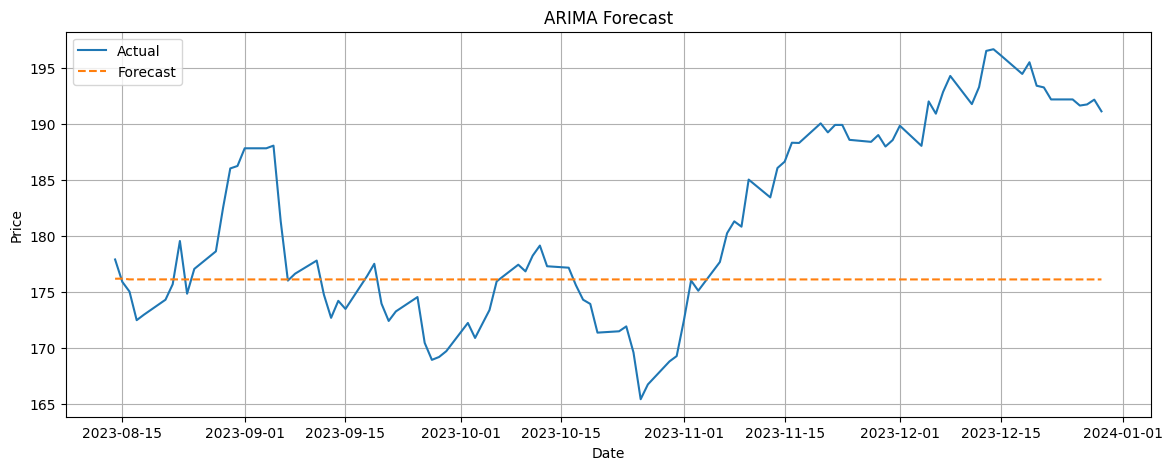

DEBUG:cmdstanpy:input tempfile: /tmp/tmpngz5qm5a/ozg77axl.json



--- Prophet ---


DEBUG:cmdstanpy:input tempfile: /tmp/tmpngz5qm5a/5r4htczr.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=85935', 'data', 'file=/tmp/tmpngz5qm5a/ozg77axl.json', 'init=/tmp/tmpngz5qm5a/5r4htczr.json', 'output', 'file=/tmp/tmpngz5qm5a/prophet_modelo2on6u97/prophet_model-20250515165919.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
16:59:19 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
16:59:20 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Prophet RMSE: 18.04


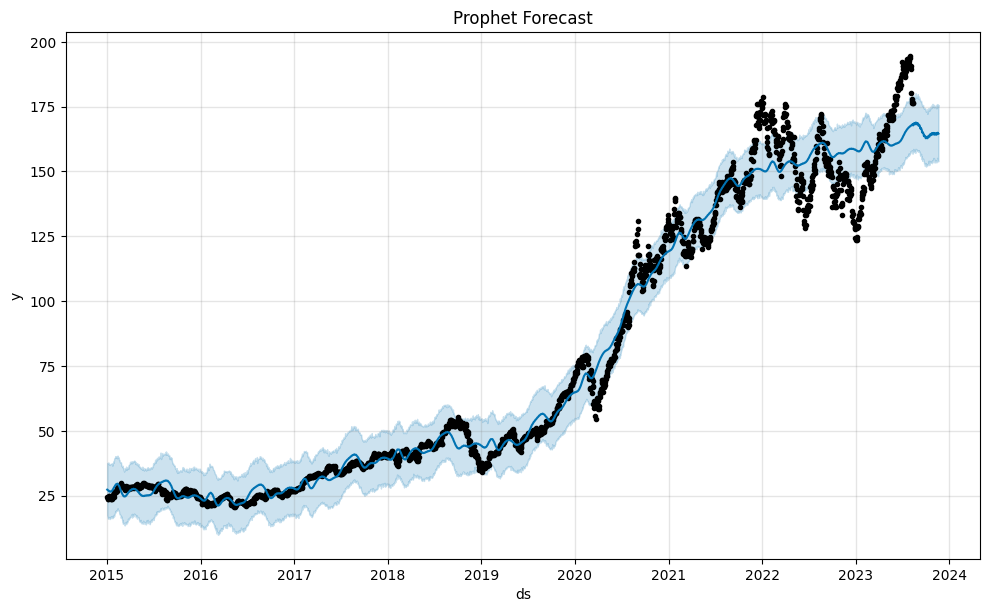


--- LSTM ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - loss: 0.0300
Epoch 2/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - loss: 5.5649e-04
Epoch 3/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 5.3659e-04
Epoch 4/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - loss: 5.4841e-04
Epoch 5/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - loss: 4.7671e-04
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step
LSTM RMSE: 9.12


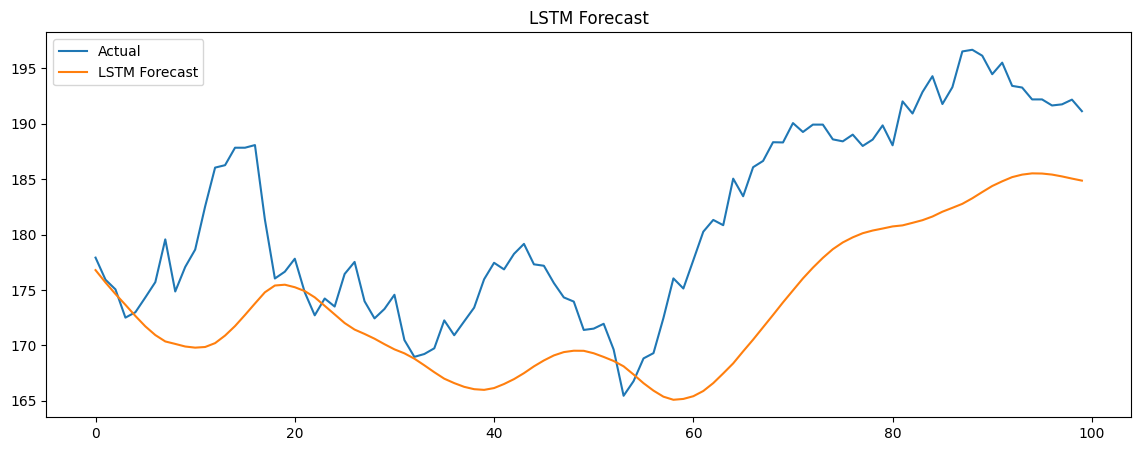

In [ ]:
def main():
    data = fetch_data("AAPL")
    plot_data(data)
    print("\n--- ARIMA ---")
    arima_model(data)
    print("\n--- Prophet ---")
    prophet_model(data)
    print("\n--- LSTM ---")
    lstm_model(data)

if __name__ == "__main__":
    main()